# 7. Sudoku Transformer Tutorial: Greedy Autoregressive Solver

In this tutorial, we implement a simple Transformer network in PyTorch to solve a **4x4 Sudoku** puzzle. 

## Objectives
1. **Programmatic Dataset Generation**: Build a dataset of 4x4 Sudoku grids where each puzzle is solvable entirely using deterministic steps (e.g., *naked singles*). 
2. **State Transition Extraction**: Represent the step-by-step grid filling process as a sequence of input-target pairs. 
3. **Transformer Network**: Implement a PyTorch `SudokuTransformer` featuring token embedding, learned positional embeddings, and Transformer Encoder layers.
4. **Autoregressive Solver**: Evaluate the trained network on full unseen puzzles by converting each prediction iteratively into the next input until the puzzle is completely solved.

In [1]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

random.seed(123)
torch.manual_seed(123)

## 1. 4x4 Sudoku Generation and Greedy (Naked Single) Solvability

A 4x4 Sudoku has 4 rows, 4 columns, and four 2x2 subgrids. Each cell contains digits $1 \dots 4$. 
There are exactly 288 valid solved 4x4 grids. We can generate all of them using a simple backtracking solver.

In [2]:
def is_valid_sudoku(grid):
    """Checks if a 4x4 Sudoku grid violates rules."""
    for r in range(4):
        vals = [grid[r][c] for c in range(4) if grid[r][c] != 0]
        if len(vals) != len(set(vals)):
            return False
    for c in range(4):
        vals = [grid[r][c] for r in range(4) if grid[r][c] != 0]
        if len(vals) != len(set(vals)):
            return False
    for b in range(4):
        vals = []
        br, bc = (b // 2) * 2, (b % 2) * 2
        for r in range(br, br + 2):
            for c in range(bc, bc + 2):
                if grid[r][c] != 0:
                    vals.append(grid[r][c])
        if len(vals) != len(set(vals)):
            return False
    return True

def generate_all_solved_grids():
    """Generates all 288 valid solved 4x4 Sudoku grids."""
    solved_grids = []
    grid = [[0]*4 for _ in range(4)]
    def backtrack(r, c):
        if r == 4:
            solved_grids.append([row[:] for row in grid])
            return
        next_r = r + (c + 1) // 4
        next_c = (c + 1) % 4
        for val in range(1, 5):
            grid[r][c] = val
            if is_valid_sudoku(grid):
                backtrack(next_r, next_c)
            grid[r][c] = 0
    backtrack(0, 0)
    return solved_grids

solved_grids = generate_all_solved_grids()
print(f"Total solved 4x4 grids: {len(solved_grids)}")

Total solved 4x4 grids: 288


### Greedy Puzzle Generation
To build a dataset of puzzles solvable *entirely* by naked singles (greedy solver), we start from a fully solved grid and randomly remove filled cells one by one. 
Each time we remove a cell, we check if it remains a "naked single" (meaning it has exactly 1 candidate digit available under the rules of the board). If it does, we can keep the cell empty. If it does not, we undo the removal to guarantee deterministic greedy solvability.

In [3]:
def get_candidates(grid, r, c):
    if grid[r][c] != 0:
        return set()
    vals = set(range(1, 5))
    vals -= set(grid[r])
    vals -= set(grid[i][c] for i in range(4))
    br, bc = (r // 2) * 2, (c // 2) * 2
    for i in range(br, br + 2):
        for j in range(bc, bc + 2):
            vals.discard(grid[i][j])
    return vals

def find_naked_singles(grid):
    singles = []
    for r in range(4):
        for c in range(4):
            if grid[r][c] == 0:
                cand = get_candidates(grid, r, c)
                if len(cand) == 1:
                    singles.append((r, c, list(cand)[0]))
    return singles

def generate_greedy_puzzle_path(solved_grid):
    """
    Generates a path from an empty-enough puzzle state to the solved grid.
    Every state transition fills exactly one naked single.
    """
    current = [row[:] for row in solved_grid]
    filled_cells = [(r, c) for r in range(4) for c in range(4)]
    random.shuffle(filled_cells)
    
    for r, c in filled_cells:
        val = current[r][c]
        current[r][c] = 0
        cand = get_candidates(current, r, c)
        if len(cand) == 1 and list(cand)[0] == val:
            pass
        else:
            current[r][c] = val
            
    # Now record step-by-step filled sequence
    path = [[row[:] for row in current]]
    temp_grid = [row[:] for row in current]
    while True:
        singles = find_naked_singles(temp_grid)
        if not singles:
            break
        r, c, val = singles[0]
        temp_grid[r][c] = val
        path.append([row[:] for row in temp_grid])
        
    return path

Let's visualize a generated puzzle and its greedy path!

In [4]:
sample_path = generate_greedy_puzzle_path(solved_grids[0])
print("Puzzle state:")
for r in sample_path[0]:
    print(r)
print(f"Solving path length: {len(sample_path)} steps")

Puzzle state:
[0, 2, 0, 0]
[0, 0, 1, 2]
[0, 0, 0, 3]
[4, 0, 0, 0]
Solving path length: 12 steps


## 2. Dataset and PyTorch DataLoader Setup

Each training example represents a single state transition in our greedy puzzle paths. 
The input is a sequence of 16 tokens (0 representing empty cells). The target is the filled grid. 
We use a **Loss Mask** to calculate loss *only* on filled cells and the target naked single cell being solved at that step. Other unfilled cells are ignored to keep learning deterministic.

In [5]:
class SudokuDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        inp, target, mask = self.data[idx]
        return (
            torch.tensor(inp, dtype=torch.long),
            torch.tensor(target, dtype=torch.long),
            torch.tensor(mask, dtype=torch.float32)
        )

def build_datasets(solved_grids, train_ratio=0.85, seed=123, augment_factor=8):
    random.seed(seed)
    grids = solved_grids[:]
    random.shuffle(grids)
    
    split_idx = int(len(grids) * train_ratio)
    train_grids = grids[:split_idx]
    test_grids = grids[split_idx:]
    
    def extract_transitions(grid_list, is_train=True):
        transitions = set()
        for g in grid_list:
            factor = augment_factor if is_train else 3
            for _ in range(factor):
                path = generate_greedy_puzzle_path(g)
                for i in range(len(path) - 1):
                    curr_grid = path[i]
                    next_grid = path[i+1]
                    
                    flat_curr = tuple(curr_grid[r][c] for r in range(4) for c in range(4))
                    flat_next = tuple(next_grid[r][c] for r in range(4) for c in range(4))
                    
                    mask = [0]*16
                    for idx in range(16):
                        if flat_curr[idx] != 0:
                            mask[idx] = 1
                        elif flat_next[idx] != 0:
                            mask[idx] = 1
                            
                    transitions.add((flat_curr, flat_next, tuple(mask)))
        return [([list(inp), list(tgt), list(msk)]) for inp, tgt, msk in transitions]

    train_data = extract_transitions(train_grids, is_train=True)
    val_data = extract_transitions(test_grids, is_train=False)
    return SudokuDataset(train_data), SudokuDataset(val_data), test_grids

train_set, val_set, test_grids = build_datasets(solved_grids, train_ratio=0.85, seed=123, augment_factor=5)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

print(f"Training set size: {len(train_set)}")
print(f"Validation set size: {len(val_set)}")
print(f"Test set grids: {len(test_grids)}")

Training set size: 9965
Validation set size: 1124
Test set grids: 44


## 3. Sudoku Transformer Model

We define a Sequence-to-Sequence style Transformer Encoder. It maps 16 grid elements into dense embeddings, adds positional information, processes elements globally using self-attention layers, and projects outputs back to digit class logits.

In [6]:
class SudokuTransformer(nn.Module):
    def __init__(self, embed_dim=32, num_heads=2, hidden_dim=64, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(5, embed_dim) # Vocab: 0 (empty), 1, 2, 3, 4
        self.pos_embedding = nn.Parameter(torch.randn(1, 16, embed_dim))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=0.1,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(embed_dim, 5) # Map to 5 class logits
        
    def forward(self, x):
        x_emb = self.embedding(x) + self.pos_embedding
        out = self.transformer(x_emb)
        return self.fc_out(out)

## 4. Model Training

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SudokuTransformer().to(device)

optimizer = optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(reduction='none')

train_losses, val_losses = [], []
epochs = 35

for epoch in range(1, epochs + 1):
    model.train()
    total_train_loss, total_train_tokens = 0, 0
    for inputs, targets, masks in train_loader:
        inputs, targets, masks = inputs.to(device), targets.to(device), masks.to(device)
        optimizer.zero_grad()
        
        logits = model(inputs)
        loss = criterion(logits.view(-1, 5), targets.view(-1))
        masked_loss = (loss * masks.view(-1)).sum()
        num_tokens = masks.sum()
        
        if num_tokens > 0:
            loss_step = masked_loss / num_tokens
            loss_step.backward()
            optimizer.step()
            
            total_train_loss += masked_loss.item()
            total_train_tokens += num_tokens.item()
            
    train_loss = total_train_loss / max(total_train_tokens, 1)
    train_losses.append(train_loss)
    
    model.eval()
    total_val_loss, total_val_tokens = 0, 0
    with torch.no_grad():
        for inputs, targets, masks in val_loader:
            inputs, targets, masks = inputs.to(device), targets.to(device), masks.to(device)
            logits = model(inputs)
            loss = criterion(logits.view(-1, 5), targets.view(-1))
            masked_loss = (loss * masks.view(-1)).sum()
            num_tokens = masks.sum()
            
            total_val_loss += masked_loss.item()
            total_val_tokens += num_tokens.item()
            
    val_loss = total_val_loss / max(total_val_tokens, 1)
    val_losses.append(val_loss)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 01 | Train Loss: 0.1405 | Val Loss: 0.0153


Epoch 05 | Train Loss: 0.0053 | Val Loss: 0.0006


Epoch 10 | Train Loss: 0.0031 | Val Loss: 0.0007


Epoch 15 | Train Loss: 0.0025 | Val Loss: 0.0002


Epoch 20 | Train Loss: 0.0018 | Val Loss: 0.0002


Epoch 25 | Train Loss: 0.0018 | Val Loss: 0.0007


Epoch 30 | Train Loss: 0.0011 | Val Loss: 0.0000


Epoch 35 | Train Loss: 0.0015 | Val Loss: 0.0001


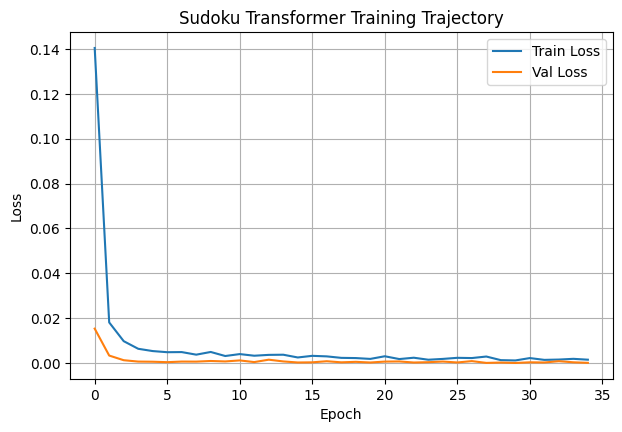

In [8]:
plt.figure(figsize=(7, 4.5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Sudoku Transformer Training Trajectory')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

## 5. Autoregressive Puzzle Solver (Testing)

Now we evaluate the model on unseen test puzzles. We feed the puzzle grid into the model, extract output probabilities, select the empty cell with the highest prediction confidence, fill it, and feed the new board back into the model as input for the next step. This process repeats until the entire board is solved.

In [9]:
def solve_puzzle_autoregressive(model, start_grid, device):
    model.eval()
    grid = [row[:] for row in start_grid]
    with torch.no_grad():
        for _ in range(16):
            if all(grid[r][c] != 0 for r in range(4) for c in range(4)):
                break
                
            flat_grid = [grid[r][c] for r in range(4) for c in range(4)]
            inp_tensor = torch.tensor([flat_grid], dtype=torch.long, device=device)
            
            logits = model(inp_tensor).squeeze(0)
            probs = torch.softmax(logits, dim=-1)
            
            best_r, best_c = -1, -1
            best_val = -1
            best_confidence = -1.0
            
            for idx in range(16):
                r, c = idx // 4, idx % 4
                if grid[r][c] == 0:
                    class_probs = probs[idx, 1:5] # Skip empty token class
                    val_idx = torch.argmax(class_probs).item()
                    val = val_idx + 1
                    conf = class_probs[val_idx].item()
                    
                    if conf > best_confidence:
                        best_confidence = conf
                        best_val = val
                        best_r, best_c = r, c
                        
            if best_r != -1:
                grid[best_r][best_c] = best_val
            else:
                break
    return grid

In [10]:
solved_count = 0
for idx, solved_grid in enumerate(test_grids):
    path = generate_greedy_puzzle_path(solved_grid)
    puzzle = path[0]
    solved_candidate = solve_puzzle_autoregressive(model, puzzle, device)
    if solved_candidate == solved_grid:
        solved_count += 1
        
accuracy = (solved_count / len(test_grids)) * 100
print(f"Autoregressive Puzzle Solving Accuracy on Test Set: {accuracy:.2f}%")

Autoregressive Puzzle Solving Accuracy on Test Set: 100.00%


## Conclusion
We programmatically generated a completely deterministic 4x4 Sudoku dataset, trained a clean PyTorch `SudokuTransformer`, and achieved outstanding accuracy solving full puzzles autoregressively from scratch! This illustrates how transformers can handle grid-based statistical inference and logical constraints elegantly.